# About the Dataset

- **The Auto Scout** dataset was obtained from the online car trading company [AutoScout24](https://www.autoscout24.com) in 2019 and includes many features of 9 different car models.

- In this project, we will use the dataset that has already been pre-processed and prepared for algorithms.

- The aim of this project is to understand machine learning algorithms. Therefore, since you will be working on cleaned data, we will not need an intensive EDA process.

- In this scenario, we will predict car prices using regression algorithms.

- To begin, we will need to import the necessary libraries. We will also need to perform a few pre-processing steps before moving on to modeling.

- Next, we will respectively apply Linear Regression, Ridge Regression, Lasso Regression, and Elastic-Net algorithms.

- We can measure the success of our models using regression error metrics and the cross-validation method.

- For better results, we will try to increase the success of your models by performing hyperparameter tuning.

- We will determine the importance of the features for the model and adjust our model with the most important features to save resources.

- Finally, we will compare the performance of the algorithms.

1. **make_model**: Contains the make and model information of the vehicles.
2. **body_type**: Indicates the body type of the vehicles (e.g., sedan, hatchback).
3. **price**: Contains the price information of the vehicles.
4. **vat**: Contains value-added tax (VAT) information (often important in vehicle sales).
5. **km**: Contains the mileage information of the vehicles.
6. **Type**: Indicates the type of the vehicle (e.g., new, used).
7. **Fuel**: Indicates the type of fuel used (e.g., petrol, diesel).
8. **Gears**: Contains the number of gears in the vehicles.
9. **Comfort_Convenience**: Contains the comfort and convenience features of the vehicles.
10. **Entertainment_Media**: Contains entertainment and media features.
11. **Extras**: Contains the extra features of the vehicles.
12. **Safety_Security**: Contains safety features.
13. **age**: The age of the vehicles.
14. **Previous_Owners**: Contains the number of previous owners of the vehicles.
15. **hp_kW**: Contains the horsepower of the vehicles in kilowatts.
16. **Inspection_new**: Contains information about whether the vehicle has a new inspection.
17. **Paint_Type**: Contains the type of paint of the vehicles.
18. **Upholstery_type**: Contains the type of upholstery in the vehicles.
19. **Gearing_Type**: Indicates the type of transmission in the vehicles.
20. **Displacement_cc**: Indicates the engine displacement in cubic centimeters (cc).
21. **Weight_kg**: Indicates the weight of the vehicles in kilograms.
22. **Drive_chain**: Indicates the type of drive train in the vehicles (e.g., front-wheel drive, rear-wheel drive).
23. **cons_comb**: Indicates the combined fuel consumption of the vehicles in liters per 100 kilometers.

# Tasks

- 1. Import Modules, Load Data and Data Review

- 2. EDA

- 3. Train | Test Split

- 4. Implement Linear Regression

- 5. Implement Ridge Regression

- 6. Implement Lasso Regression

- 7. Implement Elastic-Net

- 8. Visually Compare Models Performance In a Graph

- 9. Feature Importance

- 10. Compare Models Performance

- 11. Prediction

# Import Modules, Load Data and Data Review

In [1]:
import pandas as pd      
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline  

import warnings
warnings.filterwarnings('ignore')

In [2]:
df0 = pd.read_csv('final_scout_not_dummy.csv')
df = df0.copy()

# EDA

In [3]:
df.head()

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  object 
 1   body_type            15915 non-null  object 
 2   price                15915 non-null  int64  
 3   vat                  15915 non-null  object 
 4   km                   15915 non-null  float64
 5   Type                 15915 non-null  object 
 6   Fuel                 15915 non-null  object 
 7   Gears                15915 non-null  float64
 8   Comfort_Convenience  15915 non-null  object 
 9   Entertainment_Media  15915 non-null  object 
 10  Extras               15915 non-null  object 
 11  Safety_Security      15915 non-null  object 
 12  age                  15915 non-null  float64
 13  Previous_Owners      15915 non-null  float64
 14  hp_kW                15915 non-null  float64
 15  Inspection_new       15915 non-null 

In [5]:
df.shape

(15915, 23)

In [6]:
df.describe()

,price,km,Gears,age,Previous_Owners,hp_kW,Inspection_new,Displacement_cc,Weight_kg,cons_comb
count,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000
mean,18024.380584,32089.995708,5.937355,1.389695,1.042853,88.499340,0.247063,1428.661891,1337.700534,4.832124
std,7381.679318,36977.214964,0.704772,1.121306,0.339178,26.674341,0.431317,275.804272,199.682385,0.867530
min,4950.000000,0.000000,5.000000,0.000000,0.000000,40.000000,0.000000,890.000000,840.000000,3.000000
25%,12850.000000,1920.500000,5.000000,0.000000,1.000000,66.000000,0.000000,1229.000000,1165.000000,4.100000
50%,16900.000000,20413.000000,6.000000,1.000000,1.000000,85.000000,0.000000,1461.000000,1295.000000,4.800000
75%,21900.000000,46900.000000,6.000000,2.000000,1.000000,103.000000,0.000000,1598.000000,1472.000000,5.400000
max,74600.000000,317000.000000,8.000000,3.000000,4.000000,294.000000,1.000000,2967.000000,2471.000000,9.100000


In [7]:
df.isnull().sum()

make_model             0
body_type              0
price                  0
vat                    0
km                     0
Type                   0
Fuel                   0
Gears                  0
Comfort_Convenience    0
Entertainment_Media    0
Extras                 0
Safety_Security        0
age                    0
Previous_Owners        0
hp_kW                  0
Inspection_new         0
Paint_Type             0
Upholstery_type        0
Gearing_Type           0
Displacement_cc        0
Weight_kg              0
Drive_chain            0
cons_comb              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1673)

In [9]:
df[df.duplicated(keep=False)]

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
2,Audi A1,Sedans,14640,VAT deductible,83450.000000,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
5,Audi A1,Sedans,15090,VAT deductible,63668.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,85.0,0,Metallic,Part/Full Leather,Automatic,1598.0,1135.0,front,3.5
15,Audi A1,Sedans,18700,VAT deductible,27000.000000,Employee's car,Diesel,7.0,"Air conditioning,Armrest,Cruise control,Electr...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1275.0,front,3.7
19,Audi A1,Sedans,18500,VAT deductible,13406.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Auxiliary heating,Ele...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
81,Audi A1,Sedans,18500,VAT deductible,13406.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Auxiliary heating,Ele...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15897,Renault Espace,Van,41400,VAT deductible,10.000000,Pre-registered,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Radio,USB",...,1.0,118.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.1
15908,Renault Espace,Van,39950,VAT deductible,1647.362609,New,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Hands-free equipment,O...",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3
15910,Renault Espace,Van,39950,VAT deductible,1647.362609,New,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Hands-free equipment,O...",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3
15913,Renault Espace,Van,39700,VAT deductible,10.000000,Pre-registered,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Radio,USB",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,15915.0,18024.380584,7381.679318,4950.0,12850.0,16900.0,21900.0,74600.0
km,15915.0,32089.995708,36977.214964,0.0,1920.5,20413.0,46900.0,317000.0
Gears,15915.0,5.937355,0.704772,5.0,5.0,6.0,6.0,8.0
age,15915.0,1.389695,1.121306,0.0,0.0,1.0,2.0,3.0
Previous_Owners,15915.0,1.042853,0.339178,0.0,1.0,1.0,1.0,4.0
hp_kW,15915.0,88.499340,26.674341,40.0,66.0,85.0,103.0,294.0
Inspection_new,15915.0,0.247063,0.431317,0.0,0.0,0.0,0.0,1.0
Displacement_cc,15915.0,1428.661891,275.804272,890.0,1229.0,1461.0,1598.0,2967.0
Weight_kg,15915.0,1337.700534,199.682385,840.0,1165.0,1295.0,1472.0,2471.0
cons_comb,15915.0,4.832124,0.867530,3.0,4.1,4.8,5.4,9.1


In [11]:
df.describe(include="object").T

,count,unique,top,freq
make_model,15915,9,Audi A3,3097
body_type,15915,8,Sedans,8004
vat,15915,2,VAT deductible,15044
Type,15915,5,Used,11095
Fuel,15915,4,Benzine,8548
Comfort_Convenience,15915,6196,"Air conditioning,Electrical side mirrors,Hill ...",388
Entertainment_Media,15915,346,"Bluetooth,Hands-free equipment,On-board comput...",1737
Extras,15915,659,Alloy wheels,5785
Safety_Security,15915,4442,"ABS,Central door lock,Daytime running lights,D...",729
Paint_Type,15915,3,Metallic,15246


In [12]:
for col in df.select_dtypes('object'):
    print(f"{col:<20}:", df[col].nunique())

make_model          : 9
body_type           : 8
vat                 : 2
Type                : 5
Fuel                : 4
Comfort_Convenience : 6196
Entertainment_Media : 346
Extras              : 659
Safety_Security     : 4442
Paint_Type          : 3
Upholstery_type     : 2
Gearing_Type        : 3
Drive_chain         : 3


In [13]:
df.make_model.value_counts()

make_model
Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2525
Opel Corsa        2216
Renault Clio      1839
Renault Espace     991
Renault Duster      34
Audi A2              1
Name: count, dtype: int64

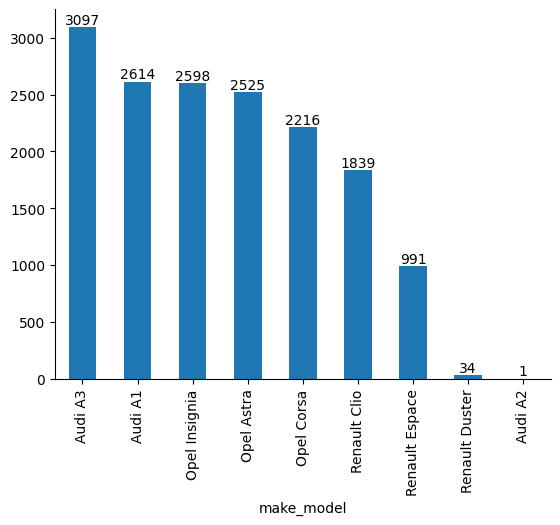

In [14]:
ax = df.make_model.value_counts().plot(kind ="bar")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.axis("off")
    
ax.bar_label(ax.containers[0]);

In [15]:
df.drop(index=[2614], inplace =True)

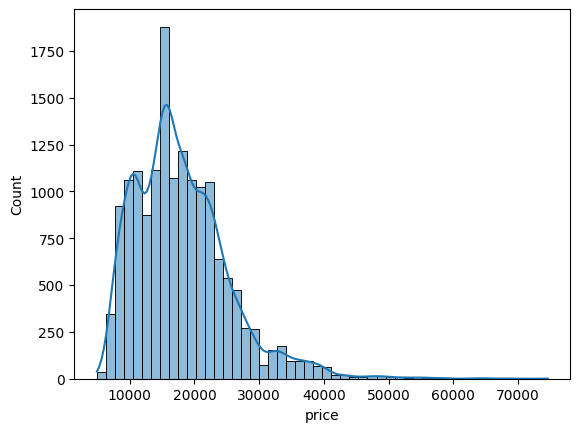

In [16]:
sns.histplot(df.price, bins=50, kde=True);

In [17]:
df_numeric = df.select_dtypes(include ="number")
df_numeric

,price,km,Gears,age,Previous_Owners,hp_kW,Inspection_new,Displacement_cc,Weight_kg,cons_comb
0,15770,56013.000000,7.0,3.0,2.0,66.0,1,1422.0,1220.0,3.8
1,14500,80000.000000,7.0,2.0,1.0,141.0,0,1798.0,1255.0,5.6
2,14640,83450.000000,7.0,3.0,1.0,85.0,0,1598.0,1135.0,3.8
3,14500,73000.000000,6.0,3.0,1.0,66.0,0,1422.0,1195.0,3.8
4,16790,16200.000000,7.0,3.0,1.0,66.0,1,1422.0,1135.0,4.1
...,...,...,...,...,...,...,...,...,...,...
15910,39950,1647.362609,6.0,0.0,1.0,147.0,0,1997.0,1758.0,5.3
15911,39885,9900.000000,7.0,0.0,1.0,165.0,0,1798.0,1708.0,7.4
15912,39875,15.000000,6.0,0.0,1.0,146.0,1,1997.0,1734.0,5.3
15913,39700,10.000000,6.0,0.0,1.0,147.0,0,1997.0,1758.0,5.3


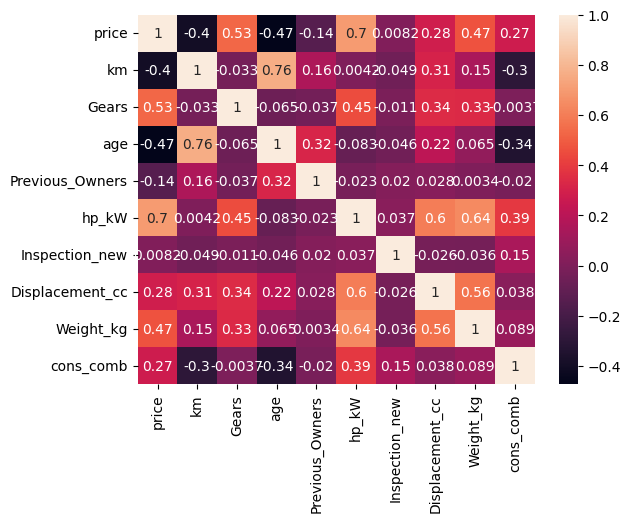

In [18]:
sns.heatmap(df_numeric.corr(), annot =True);

In [19]:
df = df.join(df["Comfort_Convenience"].str.get_dummies(sep = ",").add_prefix("cc_"))
df = df.join(df["Entertainment_Media"].str.get_dummies(sep = ",").add_prefix("em_"))
df = df.join(df["Extras"].str.get_dummies(sep = ",").add_prefix("ex_"))
df = df.join(df["Safety_Security"].str.get_dummies(sep = ",").add_prefix("ss_"))

In [20]:
df.drop(["Comfort_Convenience","Entertainment_Media","Extras","Safety_Security"], axis=1, inplace=True)

In [21]:
df = pd.get_dummies(df, drop_first =True)

In [22]:
bool_columns = df.columns[df.dtypes == 'bool']
df[bool_columns] = df[bool_columns].astype(int)

In [23]:
df.isnull().any().any()

np.False_

# Train | Test Split

In [24]:
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score

In [25]:
X = df.select_dtypes(include=["number"]).drop(columns=["price"])
y = df["price"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Implement Linear Regression

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
def train_val(model, X_train, y_train, X_test, y_test):
    
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    
    scores = {
    "train": {
    "R2" : r2_score(y_train, y_train_pred),
    "mae" : mean_absolute_error(y_train, y_train_pred),
    "mse" : mean_squared_error(y_train, y_train_pred),                          
    "rmse" : np.sqrt(mean_squared_error(y_train, y_train_pred))},
    
    "test": {
    "R2" : r2_score(y_test, y_pred),
    "mae" : mean_absolute_error(y_test, y_pred),
    "mse" : mean_squared_error(y_test, y_pred),
    "rmse" : np.sqrt(mean_squared_error(y_test, y_pred))}
               }
    
    return pd.DataFrame(scores)

In [29]:
lm = LinearRegression()
lm.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
train_val(lm, X_train, y_train, X_test, y_test)

,train,test
R2,8.909034e-01,8.856208e-01
mae,1.700029e+03,1.728915e+03
mse,5.935067e+06,6.267141e+06
rmse,2.436199e+03,2.503426e+03


In [31]:
def adj_r2(y_test, y_pred, df):
    r2 = r2_score(y_test, y_pred)       
    n = df.shape[0]                     
    p = df.shape[1]-1                   
    adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)  
    return adj_r2

In [32]:
y_pred = lm.predict(X_test)
adj_r2(y_test, y_pred, df)

0.8846640715800365

In [33]:
model = LinearRegression()
scores = cross_validate(model, X_train, y_train, scoring=['r2', 
            'neg_mean_absolute_error','neg_mean_squared_error','neg_root_mean_squared_error'],
             cv =10, return_train_score=True)

In [34]:
pd.DataFrame(scores)

,fit_time,score_time,test_r2,train_r2,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error
0,0.057480,0.006206,0.868844,0.893173,-1796.920449,-1684.021421,-7.411681e+06,-5.785086e+06,-2722.440238,-2405.220486
1,0.042058,0.003349,0.902267,0.889421,-1693.785783,-1703.931709,-5.444806e+06,-5.998631e+06,-2333.410750,-2449.210329
2,0.035693,0.003638,0.881151,0.891843,-1774.840321,-1691.681477,-6.816392e+06,-5.848346e+06,-2610.822156,-2418.335300
3,0.033131,0.003683,0.898816,0.889924,-1651.155477,-1709.193842,-5.183104e+06,-6.027224e+06,-2276.643237,-2455.040571
4,0.043770,0.005623,0.871207,0.892693,-1762.633131,-1695.891358,-6.547951e+06,-5.879632e+06,-2558.896354,-2424.795330
5,0.052797,0.005441,0.884952,0.891287,-1680.670463,-1707.823817,-5.587262e+06,-5.983669e+06,-2363.738982,-2446.153975
6,0.048413,0.005684,0.896022,0.890268,-1677.272598,-1707.885303,-4.955590e+06,-6.051837e+06,-2226.115370,-2460.048235
7,0.046599,0.004296,0.891299,0.890570,-1759.619390,-1688.670278,-7.073807e+06,-5.823359e+06,-2659.662998,-2413.163610
8,0.036772,0.005714,0.892273,0.890484,-1749.306301,-1697.121018,-6.513245e+06,-5.883601e+06,-2552.105902,-2425.613547
9,0.040525,0.004745,0.886323,0.891142,-1679.341186,-1704.871351,-5.713271e+06,-5.972209e+06,-2390.244953,-2443.810415


In [35]:
pd.DataFrame(scores).iloc[:, 2:].mean()

test_r2                              8.873154e-01
train_r2                             8.910805e-01
test_neg_mean_absolute_error        -1.722555e+03
train_neg_mean_absolute_error       -1.699109e+03
test_neg_mean_squared_error         -6.124711e+06
train_neg_mean_squared_error        -5.925359e+06
test_neg_root_mean_squared_error    -2.469408e+03
train_neg_root_mean_squared_error   -2.434139e+03
dtype: float64

In [36]:
train_val(lm, X_train, y_train, X_test, y_test)

,train,test
R2,8.909034e-01,8.856208e-01
mae,1.700029e+03,1.728915e+03
mse,5.935067e+06,6.267141e+06
rmse,2.436199e+03,2.503426e+03


In [37]:
2503/df.price.mean()

np.float64(0.13887238926767506)

In [38]:
from yellowbrick.regressor import PredictionError
from yellowbrick.features import RadViz

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


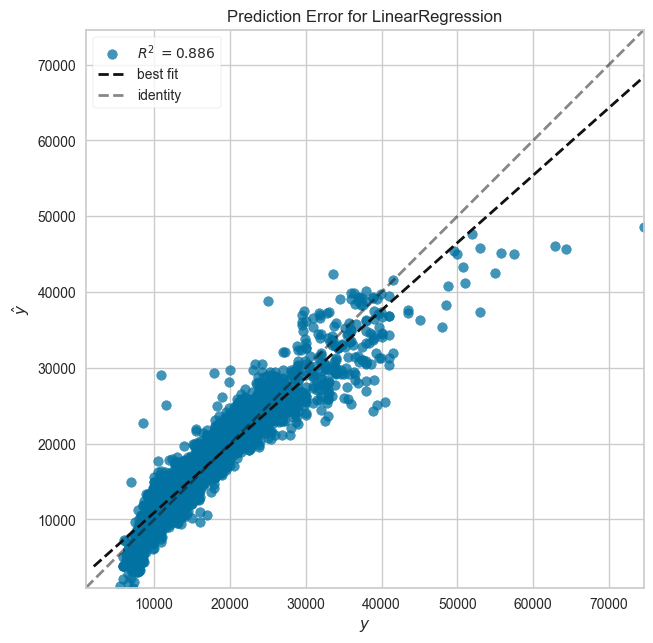

In [39]:
visualizer = RadViz(size=(720, 3000))
model = LinearRegression()
visualizer = PredictionError(model)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)  
visualizer.show();

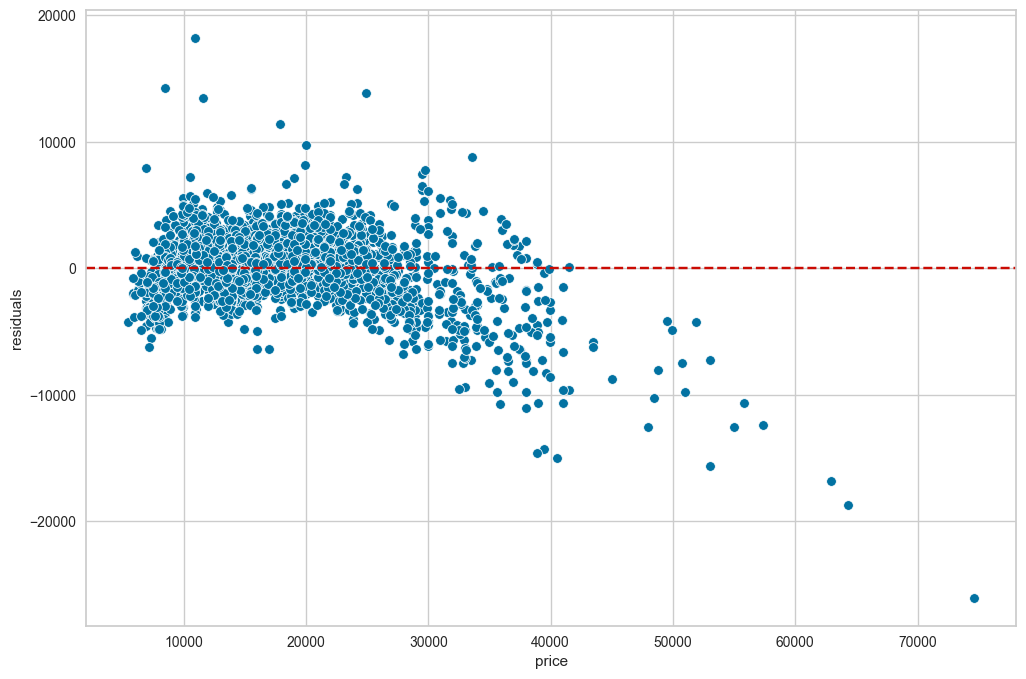

In [40]:
plt.figure(figsize=(12,8))
residuals = y_test-y_pred

sns.scatterplot(x = y_test, y = -residuals) #-residuals
plt.axhline(y = 0, color ="r", linestyle = "--")
plt.ylabel("residuals")
plt.show()

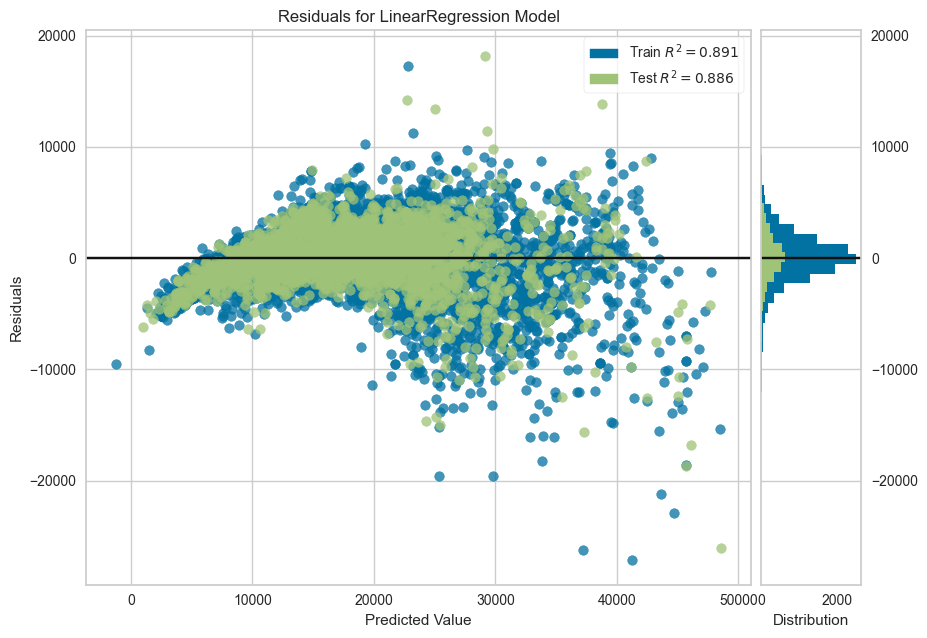

In [41]:
from yellowbrick.regressor import ResidualsPlot

visualizer = RadViz(size=(1000, 720))
model = LinearRegression()
visualizer = ResidualsPlot(model)

visualizer.fit(X_train, y_train) 
visualizer.score(X_test, y_test) 
visualizer.show(); 

In [42]:
df1 = df[~(df.price>35000)]
df1.head()

,price,km,Gears,age,Previous_Owners,hp_kW,Inspection_new,Displacement_cc,Weight_kg,cons_comb,...,Fuel_Diesel,Fuel_Electric,Fuel_LPG/CNG,Paint_Type_Perl effect,Paint_Type_Uni/basic,Upholstery_type_Part/Full Leather,Gearing_Type_Manual,Gearing_Type_Semi-automatic,Drive_chain_front,Drive_chain_rear
0,15770,56013.0,7.0,3.0,2.0,66.0,1,1422.0,1220.0,3.8,...,1,0,0,0,0,0,0,0,1,0
1,14500,80000.0,7.0,2.0,1.0,141.0,0,1798.0,1255.0,5.6,...,0,0,0,0,0,0,0,0,1,0
2,14640,83450.0,7.0,3.0,1.0,85.0,0,1598.0,1135.0,3.8,...,1,0,0,0,0,0,0,0,1,0
3,14500,73000.0,6.0,3.0,1.0,66.0,0,1422.0,1195.0,3.8,...,1,0,0,0,0,0,0,0,1,0
4,16790,16200.0,7.0,3.0,1.0,66.0,1,1422.0,1135.0,4.1,...,1,0,0,0,0,0,0,0,1,0


In [43]:
len(df[df.price>35000])

495

In [44]:
X = df1.drop(columns = "price")
y = df1.price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [45]:
lm2 = LinearRegression()
lm2.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


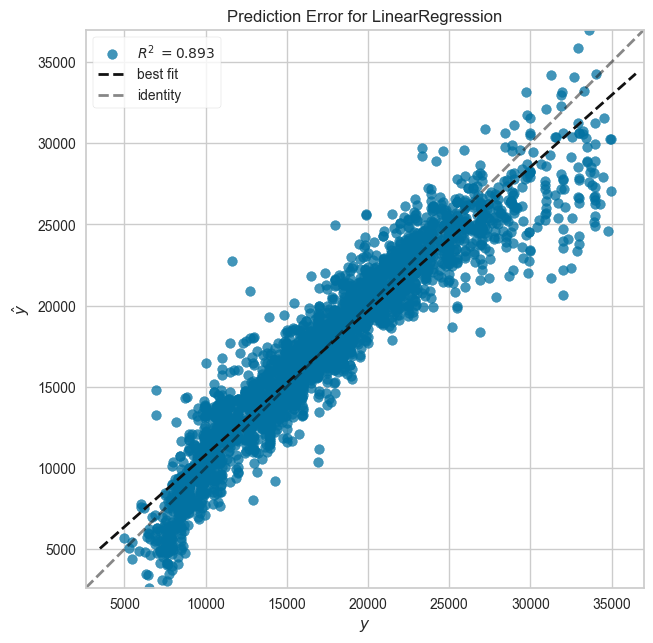

In [46]:
visualizer = RadViz(size=(720, 3000))
model = LinearRegression()
visualizer = PredictionError(model)
visualizer.fit(X_train, y_train) 
visualizer.score(X_test, y_test)
visualizer.show();

In [47]:
train_val(lm2, X_train, y_train, X_test, y_test)

,train,test
R2,9.014285e-01,8.925068e-01
mae,1.406777e+03,1.432338e+03
mse,3.732548e+06,3.920801e+06
rmse,1.931980e+03,1.980101e+03


In [48]:
1980/df1.price.mean()

np.float64(0.11452883720459127)

In [49]:
2503/df.price.mean()  #first model

np.float64(0.13887238926767506)

In [50]:
y_pred = lm2.predict(X_test)

lm_R2 = r2_score(y_test, y_pred)
lm_mae = mean_absolute_error(y_test, y_pred)
lm_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [51]:
my_dict = { 'Actual': y_test, 'Pred': y_pred, 'Residual': y_test-y_pred }
compare = pd.DataFrame(my_dict)

In [52]:
comp_sample = compare.sample(20)
comp_sample

,Actual,Pred,Residual
8027,16360,17417.711496,-1057.711496
12802,33490,28899.839363,4590.160637
1577,22940,22046.106552,893.893448
14197,9650,7200.311241,2449.688759
2153,24900,24068.899916,831.100084
7194,18250,19216.057620,-966.057620
3830,21500,18991.334106,2508.665894
11249,21980,22214.377469,-234.377469
1480,16380,17262.833175,-882.833175
4200,18499,18496.449960,2.550040


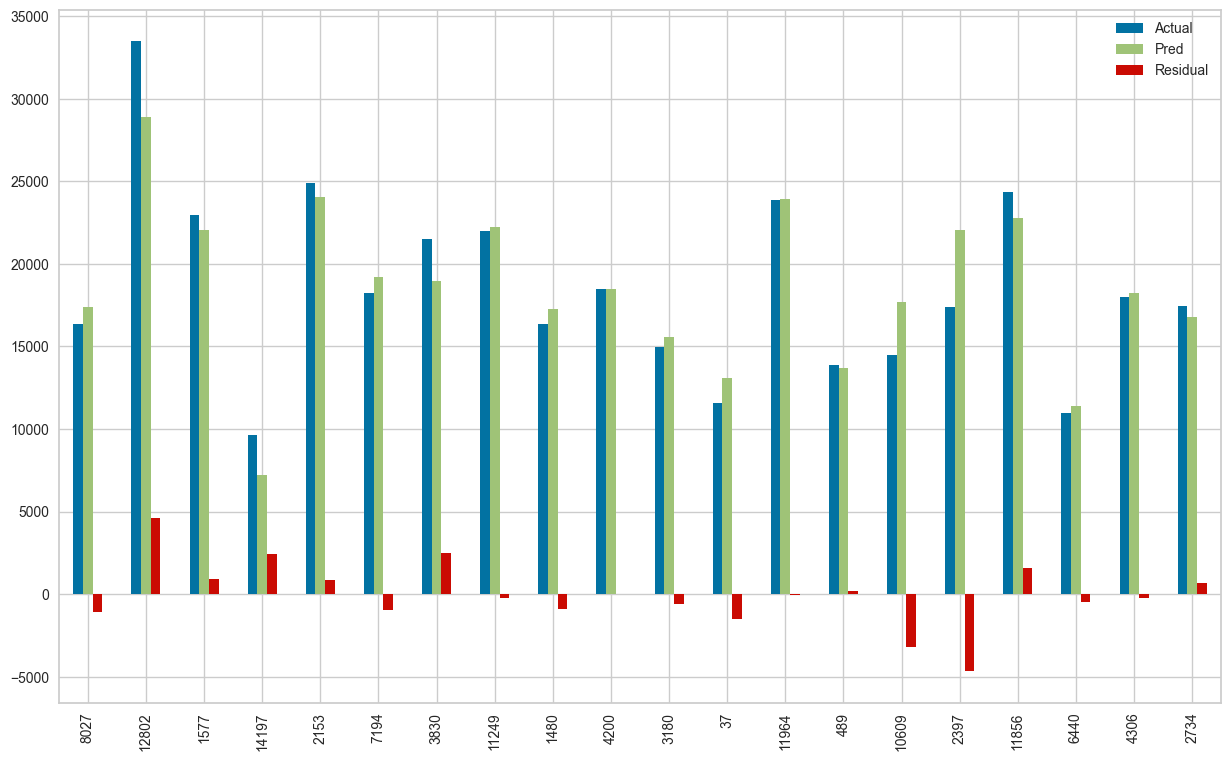

In [53]:
comp_sample.plot(kind='bar',figsize=(15,9))
plt.show()

In [54]:
pd.DataFrame(lm2.coef_, index = X.columns, columns=["Coef"]).sort_values("Coef")

,Coef
make_model_Renault Duster,-10053.838106
make_model_Renault Clio,-5574.890105
make_model_Opel Corsa,-5408.801500
make_model_Opel Astra,-3503.177288
Drive_chain_rear,-2132.166787
...,...
Paint_Type_Perl effect,1607.499243
body_type_Van,1738.253718
Gearing_Type_Semi-automatic,1934.460908
body_type_Off-Road,2111.066489


In [55]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline

In [56]:
operations = [("scaler", MinMaxScaler()), ("linear", LinearRegression())]

In [57]:
pipe_model = Pipeline(steps=operations)

In [58]:
pipe_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('linear', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [59]:
train_val(pipe_model, X_train, y_train, X_test, y_test)

,train,test
R2,9.014285e-01,8.925068e-01
mae,1.406777e+03,1.432338e+03
mse,3.732548e+06,3.920801e+06
rmse,1.931980e+03,1.980101e+03


# Implement Ridge Regression

In [60]:
from sklearn.linear_model import Ridge, RidgeCV

In [61]:
scaler = MinMaxScaler()
scaler.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [62]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
ridge_model = Ridge(alpha=1, random_state=42)

In [64]:
ridge_model.fit(X_train_scaled, y_train)

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


In [65]:
train_val(ridge_model, X_train_scaled, y_train, X_test_scaled, y_test)

,train,test
R2,9.013902e-01,8.925005e-01
mae,1.406486e+03,1.433358e+03
mse,3.733998e+06,3.921029e+06
rmse,1.932356e+03,1.980159e+03


**Finding best alpha for Ridge**

In [66]:
from sklearn.model_selection import GridSearchCV

In [67]:
alpha_space = np.linspace(0.01, 100, 100)
alpha_space

array([1.000e-02, 1.020e+00, 2.030e+00, 3.040e+00, 4.050e+00, 5.060e+00,
       6.070e+00, 7.080e+00, 8.090e+00, 9.100e+00, 1.011e+01, 1.112e+01,
       1.213e+01, 1.314e+01, 1.415e+01, 1.516e+01, 1.617e+01, 1.718e+01,
       1.819e+01, 1.920e+01, 2.021e+01, 2.122e+01, 2.223e+01, 2.324e+01,
       2.425e+01, 2.526e+01, 2.627e+01, 2.728e+01, 2.829e+01, 2.930e+01,
       3.031e+01, 3.132e+01, 3.233e+01, 3.334e+01, 3.435e+01, 3.536e+01,
       3.637e+01, 3.738e+01, 3.839e+01, 3.940e+01, 4.041e+01, 4.142e+01,
       4.243e+01, 4.344e+01, 4.445e+01, 4.546e+01, 4.647e+01, 4.748e+01,
       4.849e+01, 4.950e+01, 5.051e+01, 5.152e+01, 5.253e+01, 5.354e+01,
       5.455e+01, 5.556e+01, 5.657e+01, 5.758e+01, 5.859e+01, 5.960e+01,
       6.061e+01, 6.162e+01, 6.263e+01, 6.364e+01, 6.465e+01, 6.566e+01,
       6.667e+01, 6.768e+01, 6.869e+01, 6.970e+01, 7.071e+01, 7.172e+01,
       7.273e+01, 7.374e+01, 7.475e+01, 7.576e+01, 7.677e+01, 7.778e+01,
       7.879e+01, 7.980e+01, 8.081e+01, 8.182e+01, 

In [68]:
ridge_model = Ridge(random_state=42) 

In [69]:
param_grid = {"alpha":alpha_space}

In [70]:
ridge_grid_model = GridSearchCV(estimator=ridge_model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=10,
                          n_jobs = -1)

In [71]:
ridge_grid_model.fit(X_train_scaled,y_train) 

,estimator,Ridge(random_state=42)
,param_grid,"{'alpha': array([1.000e...1, 1.000e+02])}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(1.02)


In [72]:
ridge_grid_model.best_params_

{'alpha': np.float64(1.02)}

In [73]:
ridge_grid_model.best_estimator_

,alpha,np.float64(1.02)
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


In [74]:
pd.DataFrame(ridge_grid_model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.064109,0.006698,0.002841,0.000392,0.01,{'alpha': 0.01},-1846.720801,-2012.195044,-1937.863491,-1999.580687,-1968.254261,-1862.746436,-1932.745614,-2115.350621,-2016.120289,-1933.649148,-1962.522639,74.696973,3
1,0.069769,0.006664,0.002676,0.000245,1.02,{'alpha': 1.02},-1847.547022,-2015.047611,-1935.817000,-1998.532131,-1967.558757,-1862.127705,-1931.827196,-2114.355159,-2012.288440,-1932.487323,-1961.758834,74.472069,1
2,0.079074,0.006707,0.002767,0.000354,2.03,{'alpha': 2.03},-1848.852015,-2018.609070,-1934.874827,-1998.340083,-1967.951016,-1862.665200,-1931.825263,-2114.109746,-2010.542587,-1932.339311,-1962.010912,74.330528,2
3,0.082490,0.006517,0.003388,0.000919,3.04,{'alpha': 3.04},-1850.314100,-2022.315611,-1934.582088,-1998.582724,-1968.885202,-1863.545397,-1932.257642,-2114.250637,-2009.833356,-1932.740396,-1962.730715,74.260451,4
4,0.084525,0.006204,0.002835,0.000335,4.05,{'alpha': 4.05},-1851.855380,-2026.007849,-1934.703485,-1999.105247,-1970.120125,-1864.621298,-1932.974911,-2114.619371,-2009.764023,-1933.488782,-1963.726047,74.228644,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.092063,0.008946,0.003517,0.002076,95.96,{'alpha': 95.96000000000001},-1977.743962,-2211.229601,-2041.667825,-2131.870550,-2112.653215,-2001.430257,-2074.416715,-2213.023279,-2152.331051,-2076.199260,-2099.256572,76.381470,96
96,0.091139,0.016924,0.003224,0.000721,96.97,{'alpha': 96.97000000000001},-1978.847164,-2212.566229,-2042.715975,-2133.176392,-2113.953023,-2002.671539,-2075.722050,-2214.027032,-2153.695265,-2077.518080,-2100.489275,76.404595,97
97,0.083982,0.007787,0.003102,0.000329,97.98,{'alpha': 97.98},-1979.946693,-2213.895967,-2043.761339,-2134.478254,-2115.248438,-2003.908586,-2077.022458,-2215.028172,-2155.054631,-2078.831955,-2101.717649,76.427575,98
98,0.087995,0.008678,0.003216,0.000670,98.99,{'alpha': 98.99000000000001},-1981.042603,-2215.218932,-2044.803957,-2135.776183,-2116.539512,-2005.141462,-2078.318001,-2216.026728,-2156.409207,-2080.140946,-2102.941753,76.450411,99


In [75]:
ridge_grid_model.best_index_

np.int64(1)

In [76]:
train_val(ridge_grid_model, X_train_scaled, y_train, X_test_scaled, y_test)

,train,test
R2,9.013888e-01,8.924994e-01
mae,1.406484e+03,1.433380e+03
mse,3.734049e+06,3.921070e+06
rmse,1.932369e+03,1.980169e+03


In [77]:
y_pred = ridge_grid_model.predict(X_test_scaled)
rm_R2 = r2_score(y_test, y_pred)
rm_mae = mean_absolute_error(y_test, y_pred)
rm_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [78]:
ridge = Ridge(alpha=1.02, random_state=42).fit(X_train_scaled, y_train)
pd.DataFrame(ridge.coef_, index = X.columns, columns=["Coef"]).sort_values("Coef")

,Coef
km,-10506.712797
make_model_Renault Duster,-8892.504846
make_model_Renault Clio,-5546.363236
make_model_Opel Corsa,-5414.614920
age,-4445.961098
...,...
body_type_Van,1714.440247
Gears,1827.494457
Gearing_Type_Semi-automatic,1930.755479
make_model_Renault Espace,2656.422052


# Implement Lasso Regression

In [79]:
from sklearn.linear_model import Lasso

In [80]:
lasso_model = Lasso(random_state=42, alpha=1)

In [81]:
lasso_model.fit(X_train_scaled, y_train)

,alpha,1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [82]:
train_val(lasso_model, X_train_scaled, y_train, X_test_scaled, y_test)

,train,test
R2,9.010733e-01,8.924244e-01
mae,1.408177e+03,1.435892e+03
mse,3.745995e+06,3.923806e+06
rmse,1.935457e+03,1.980860e+03


**Finding best alpha for Lasso**

In [83]:
lasso_model = Lasso(random_state=42)
param_grid = {'alpha':alpha_space}
lasso_grid_model = GridSearchCV(estimator=lasso_model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=10,
                          n_jobs = -1)

In [84]:
lasso_grid_model.fit(X_train_scaled,y_train)

,estimator,Lasso(random_state=42)
,param_grid,"{'alpha': array([1.000e...1, 1.000e+02])}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(1.02)


In [85]:
lasso_grid_model.best_params_

{'alpha': np.float64(1.02)}

In [86]:
train_val(lasso_grid_model, X_train_scaled, y_train, X_test_scaled, y_test)

,train,test
R2,9.010617e-01,8.924145e-01
mae,1.408233e+03,1.436003e+03
mse,3.746434e+06,3.924169e+06
rmse,1.935571e+03,1.980952e+03


In [87]:
y_pred = lasso_grid_model.predict(X_test_scaled)
lasm_R2 = r2_score(y_test, y_pred)
lasm_mae = mean_absolute_error(y_test, y_pred)
lasm_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [88]:
lasso = Lasso(alpha=1.02, random_state=42).fit(X_train_scaled, y_train)
pd.DataFrame(lasso.coef_, index = X.columns, columns=["Coef"]).sort_values("Coef")

,Coef
km,-10512.528738
make_model_Renault Duster,-7808.490295
make_model_Renault Clio,-5489.756780
make_model_Opel Corsa,-5404.088375
age,-4456.835129
...,...
body_type_Van,1690.883894
Gears,1779.717547
Gearing_Type_Semi-automatic,1847.163612
make_model_Renault Espace,2578.238411


# Implement Elastic-Net

In [89]:
from sklearn.linear_model import ElasticNet

In [90]:
elastic_model = ElasticNet(random_state=42)
elastic_model.fit(X_train_scaled,y_train)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [91]:
train_val(elastic_model, X_train_scaled, y_train, X_test_scaled, y_test)

,train,test
R2,6.001616e-01,5.972966e-01
mae,3.078053e+03,3.021189e+03
mse,1.514044e+07,1.468856e+07
rmse,3.891071e+03,3.832565e+03


**Finding best alpha and l1_ratio for ElasticNet**

In [92]:
elastic_model = ElasticNet(random_state=42)

In [93]:
param_grid = {'alpha':[1.02, 2,  3, 4, 5, 7, 10, 11],
              'l1_ratio':[.5, .7, .9, .95, .99, 1]}
elastic_grid_model = GridSearchCV(estimator=elastic_model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=10,
                          n_jobs = -1)

In [94]:
elastic_grid_model.fit(X_train_scaled,y_train)

,estimator,ElasticNet(random_state=42)
,param_grid,"{'alpha': [1.02, 2, ...], 'l1_ratio': [0.5, 0.7, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1.02


In [95]:
elastic_grid_model.best_params_

{'alpha': 1.02, 'l1_ratio': 1}

In [96]:
train_val(elastic_grid_model, X_train_scaled, y_train, X_test_scaled, y_test)

,train,test
R2,9.010617e-01,8.924145e-01
mae,1.408233e+03,1.436003e+03
mse,3.746434e+06,3.924169e+06
rmse,1.935571e+03,1.980952e+03


In [97]:
y_pred = elastic_grid_model.predict(X_test_scaled)
em_R2 = r2_score(y_test, y_pred)
em_mae = mean_absolute_error(y_test, y_pred)
em_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [98]:
y_pred

array([22694.11641195, 16543.71333024, 15279.05729259, ...,
       15536.75916438, 12381.08184542, 19599.8432345 ], shape=(3084,))

In [99]:
em_R2

0.8924144579512326

In [100]:
em_mae

1436.0032214563823

In [101]:
em_rmse

np.float64(1980.9516532018924)

# Feature Importance

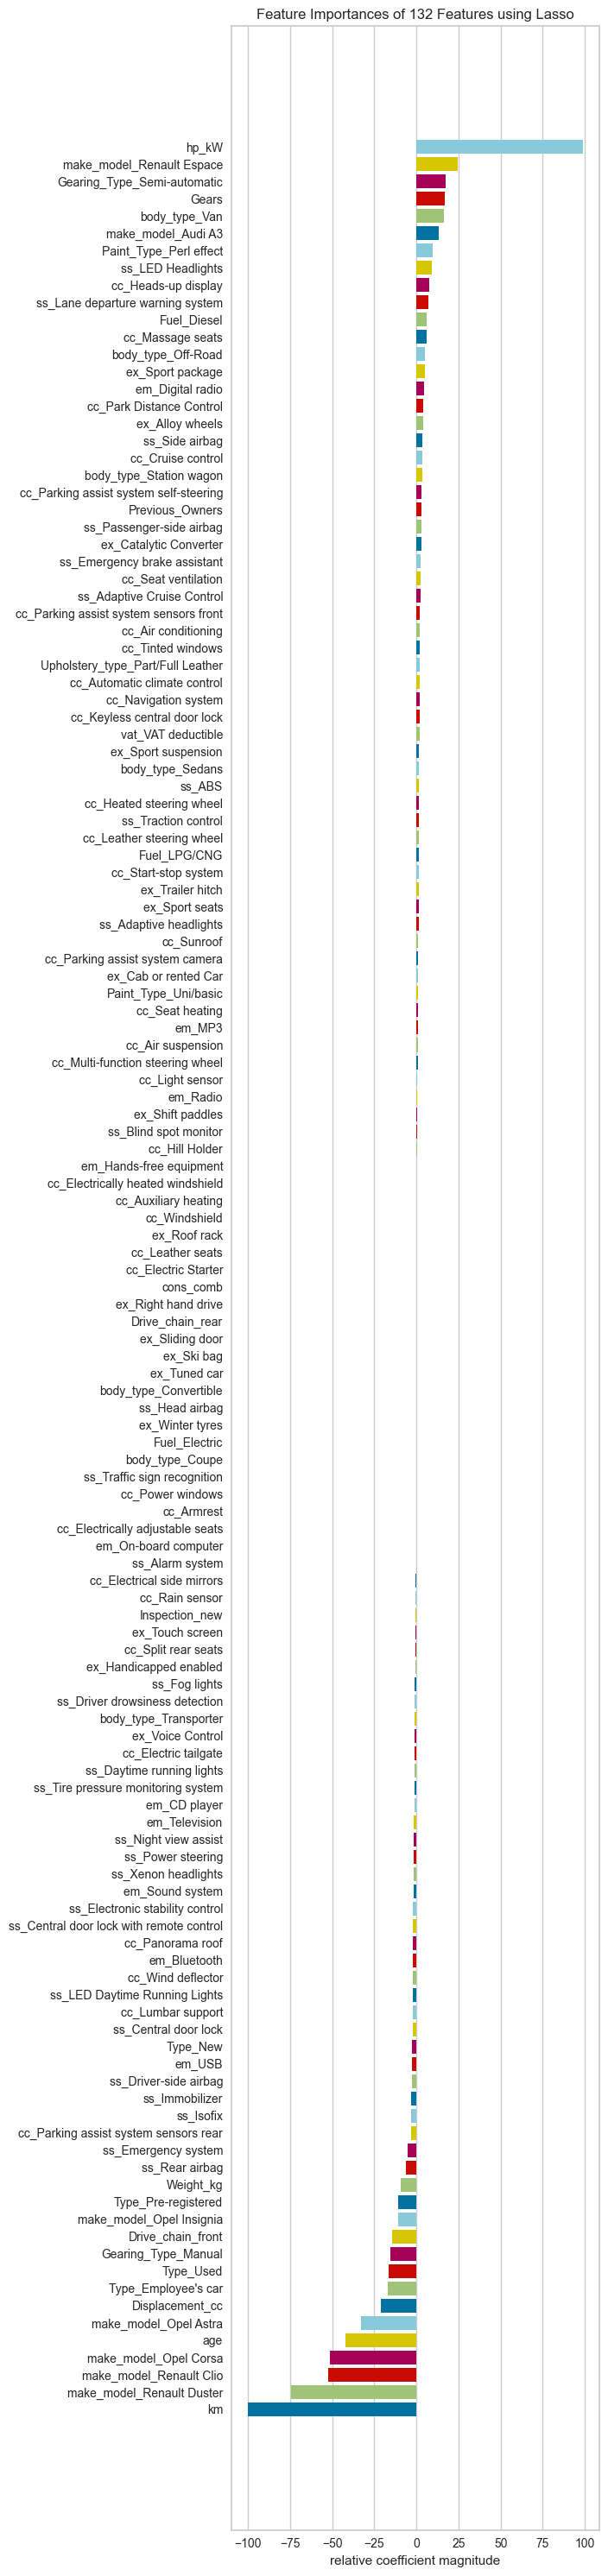

<Axes: title={'center': 'Feature Importances of 132 Features using Lasso'}, xlabel='relative coefficient magnitude'>

In [102]:
from yellowbrick.model_selection import FeatureImportances
from yellowbrick.features import RadViz

viz = FeatureImportances(Lasso(alpha=1.02), labels=X_train.columns)
visualizer = RadViz(size=(720, 3000))
viz.fit(X_train_scaled, y_train)
viz.show()

In [103]:
df_new = df0[["make_model", "hp_kW", "km", "age", "Gearing_Type", "price"]]

In [104]:
df_new.head()

,make_model,hp_kW,km,age,Gearing_Type,price
0,Audi A1,66.0,56013.0,3.0,Automatic,15770
1,Audi A1,141.0,80000.0,2.0,Automatic,14500
2,Audi A1,85.0,83450.0,3.0,Automatic,14640
3,Audi A1,66.0,73000.0,3.0,Automatic,14500
4,Audi A1,66.0,16200.0,3.0,Automatic,16790


In [105]:
df_new[df_new["make_model"] == "Audi A2"]

,make_model,hp_kW,km,age,Gearing_Type,price
2614,Audi A2,85.0,26166.0,1.0,Manual,28200


In [106]:
df_new.drop(index=[2614], inplace=True)

In [107]:
df_new = df_new[~(df_new.price > 35000)]

In [108]:
df_new = pd.get_dummies(df_new)
df_new.head()

,hp_kW,km,age,price,make_model_Audi A1,make_model_Audi A3,make_model_Opel Astra,make_model_Opel Corsa,make_model_Opel Insignia,make_model_Renault Clio,make_model_Renault Duster,make_model_Renault Espace,Gearing_Type_Automatic,Gearing_Type_Manual,Gearing_Type_Semi-automatic
0,66.0,56013.0,3.0,15770,True,False,False,False,False,False,False,False,True,False,False
1,141.0,80000.0,2.0,14500,True,False,False,False,False,False,False,False,True,False,False
2,85.0,83450.0,3.0,14640,True,False,False,False,False,False,False,False,True,False,False
3,66.0,73000.0,3.0,14500,True,False,False,False,False,False,False,False,True,False,False
4,66.0,16200.0,3.0,16790,True,False,False,False,False,False,False,False,True,False,False


In [109]:
X = df_new.drop(columns=["price"])
y = df_new.price

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [111]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [112]:
lasso_model = Lasso(random_state=42)
param_grid = {'alpha': alpha_space}
lasso_final_model = GridSearchCV(estimator=lasso_model,
                                 param_grid=param_grid,
                                 scoring='neg_root_mean_squared_error',
                                 cv=10,
                                 n_jobs=-1)

In [113]:
lasso_final_model.fit(X_train_scaled, y_train)

,estimator,Lasso(random_state=42)
,param_grid,"{'alpha': array([1.000e...1, 1.000e+02])}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(0.01)


In [114]:
lasso_final_model.best_params_

{'alpha': np.float64(0.01)}

In [115]:
lasso_final_model.best_score_

np.float64(-2239.588352950935)

In [116]:
train_val(lasso_final_model, X_train_scaled, y_train, X_test_scaled, y_test)

,train,test
R2,8.674281e-01,8.766417e-01
mae,1.611742e+03,1.553998e+03
mse,5.007031e+06,4.547724e+06
rmse,2.237640e+03,2.132539e+03


In [117]:
2132 / df_new.price.mean()

np.float64(0.1233209499596912)

In [118]:
y_pred = lasso_final_model.predict(X_test_scaled)
fm_R2 = r2_score(y_test, y_pred)
fm_mae = mean_absolute_error(y_test, y_pred)
fm_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Compare Models Performance

In [119]:
scores = {
    "linear_m": {
        "r2_score": lm_R2,
        "mae": lm_mae,
        "rmse": lm_rmse
    },
    "ridge_m": {
        "r2_score": rm_R2,
        "mae": rm_mae,
        "rmse": rm_rmse
    },
    "lasso_m": {
        "r2_score": lasm_R2,
        "mae": lasm_mae,
        "rmse": lasm_rmse
    },
    "elastic_m": {
        "r2_score": em_R2,
        "mae": em_mae,
        "rmse": em_rmse
    },
    "final_m": {
        "r2_score": fm_R2,
        "mae": fm_mae,
        "rmse": fm_rmse
    }
}
scores = pd.DataFrame(scores).T
scores

,r2_score,mae,rmse
linear_m,0.892507,1432.338423,1980.101366
ridge_m,0.892499,1433.379833,1980.169110
lasso_m,0.892414,1436.003221,1980.951653
elastic_m,0.892414,1436.003221,1980.951653
final_m,0.876642,1553.998360,2132.539402


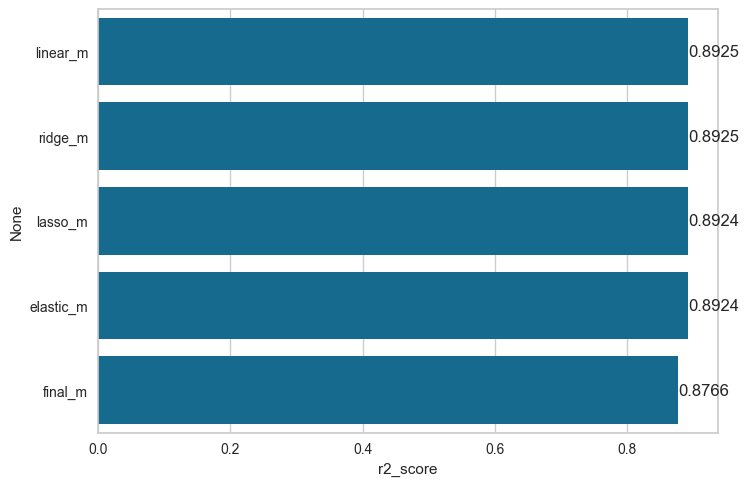

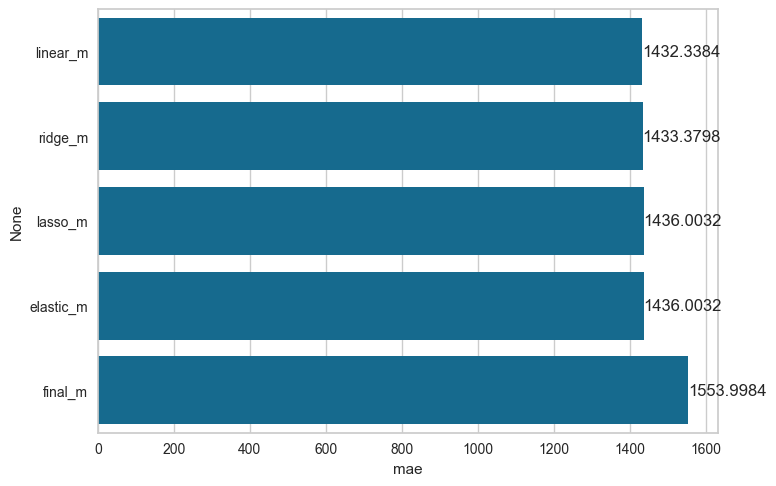

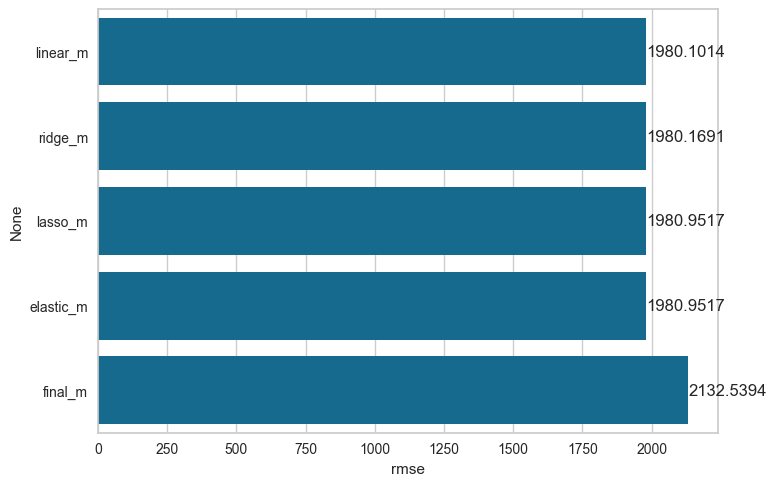

In [120]:
for i, j in enumerate(scores):
    plt.figure(i)
    if j == "r2_score":
        ascending = False
    else:
        ascending = True
    compare = scores.sort_values(by=j, ascending=ascending)
    ax = sns.barplot(x = compare[j] , y= compare.index)
    for p in ax.patches:
            width = p.get_width()                        
            ax.text(width,                               
                    p.get_y() + p.get_height() / 2,   
                    '{:.4f}'.format(width),            
                    ha = 'left',                         
                    va = 'center') 

# Prediction new observation

In [121]:
final_scaler = MinMaxScaler()
final_scaler.fit(X)
X_scaled = final_scaler.transform(X)

In [122]:
lasso_model = Lasso()
param_grid = {'alpha': alpha_space}
final_model = GridSearchCV(estimator=lasso_model,
                           param_grid=param_grid,
                           scoring='neg_root_mean_squared_error',
                           cv=10,
                           n_jobs=-1)

In [123]:
final_model.fit(X_scaled, y)

,estimator,Lasso()
,param_grid,"{'alpha': array([1.000e...1, 1.000e+02])}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(0.01)


In [124]:
final_model.best_estimator_

,alpha,np.float64(0.01)
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [125]:
my_dict = {
    "hp_kW": 66,
    "age": 2,
    "km": 17000,
    "make_model": 'Audi A3',
    "Gearing_Type": "Automatic"
}

In [126]:
my_dict = pd.DataFrame([my_dict])
my_dict

,hp_kW,age,km,make_model,Gearing_Type
0,66,2,17000,Audi A3,Automatic


In [127]:
my_dict = pd.get_dummies(my_dict)
my_dict

,hp_kW,age,km,make_model_Audi A3,Gearing_Type_Automatic
0,66,2,17000,True,True


In [128]:
X.head(1)

,hp_kW,km,age,make_model_Audi A1,make_model_Audi A3,make_model_Opel Astra,make_model_Opel Corsa,make_model_Opel Insignia,make_model_Renault Clio,make_model_Renault Duster,make_model_Renault Espace,Gearing_Type_Automatic,Gearing_Type_Manual,Gearing_Type_Semi-automatic
0,66.0,56013.0,3.0,True,False,False,False,False,False,False,False,True,False,False


In [129]:
my_dict = my_dict.reindex(columns=X.columns, fill_value=0)
my_dict

,hp_kW,km,age,make_model_Audi A1,make_model_Audi A3,make_model_Opel Astra,make_model_Opel Corsa,make_model_Opel Insignia,make_model_Renault Clio,make_model_Renault Duster,make_model_Renault Espace,Gearing_Type_Automatic,Gearing_Type_Manual,Gearing_Type_Semi-automatic
0,66,17000,2,0,True,0,0,0,0,0,0,True,0,0


In [130]:
my_dict = final_scaler.transform(my_dict)
my_dict

array([[0.13065327, 0.05362776, 0.66666667, 0.        , 1.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 1.        , 0.        , 0.        ]])

In [131]:
final_model.predict(my_dict)

array([19559.29001107])

In [132]:
final_scaler = MinMaxScaler()
final_scaler.fit(X)
X_scaled = final_scaler.transform(X)

In [133]:
lasso_model = Lasso()
param_grid = {'alpha': alpha_space}
final_model = GridSearchCV(estimator=lasso_model,
                           param_grid=param_grid,
                           scoring='neg_root_mean_squared_error',
                           cv=10,
                           n_jobs=-1)

In [134]:
final_model.fit(X_scaled, y)

,estimator,Lasso()
,param_grid,"{'alpha': array([1.000e...1, 1.000e+02])}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(0.01)


In [135]:
final_model.best_estimator_

,alpha,np.float64(0.01)
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [136]:
random_samples = df_new.sample(n=20)

In [137]:
X_random = random_samples.drop(columns=["price"])

In [138]:
X_random = final_scaler.transform(X_random)

In [139]:
predictions = final_model.predict(X_random)
predictions

array([20141.05583925, 20389.08640745, 19438.85029481, 20527.7329657 ,
       24966.83599799, 28634.77263582, 13288.25264622,  3624.81675765,
       16044.79273029, 15152.13696694, 12480.18217176, 20080.12102504,
       21785.78160339, 22666.34525475, 25485.68149778, 23923.3259724 ,
       22193.54547058, 14931.44164719, 22056.64474206, 15005.04923723])

In [140]:
true_labels = random_samples["price"].values
true_labels

array([18999, 15900, 17850, 19990, 26500, 31200, 13625,  6900, 14213,
       12450, 10940, 21300, 21900, 22900, 24990, 21222, 18490, 14490,
       16900, 15990])

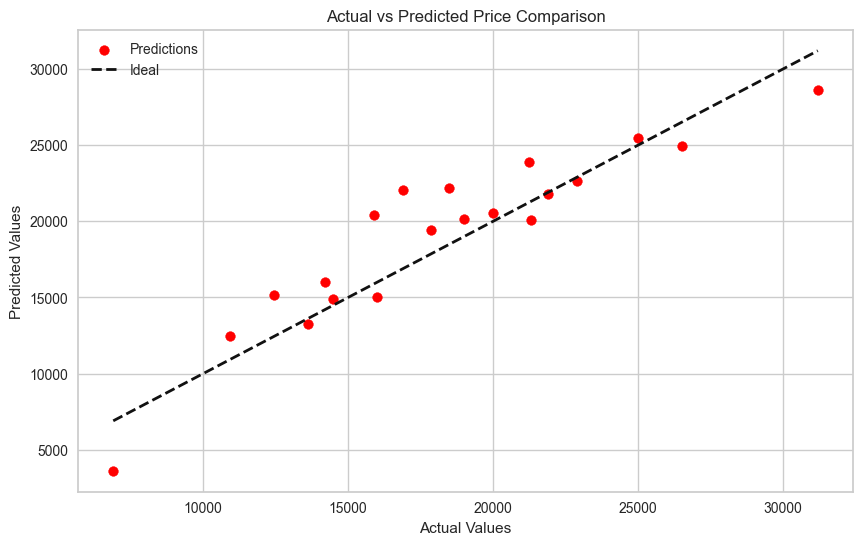

In [141]:
plt.figure(figsize=(10, 6))
plt.scatter(true_labels, predictions, color='red', label='Predictions')
plt.plot([min(true_labels), max(true_labels)], [min(true_labels), max(true_labels)], 'k--', lw=2, label='Ideal')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Price Comparison')
plt.legend()
plt.show()